# Heart Disease UCI - Exploratory Data Analysis (EDA)

**MLOps Assignment 01 - Task 1: Data Acquisition & EDA**

This notebook loads the Heart Disease UCI (Cleveland) dataset, performs cleaning
and missing-value handling, and produces professional visualizations:

* Missing value analysis
* Class / target distribution
* Histograms of numeric features
* Correlation heatmap
* Feature-vs-target relationship analysis

The dataset (303 patients, 13 clinical features + diagnosis) is acquired with
`python data/download_data.py`, which uses the official `ucimlrepo` package
(UCI id=45) with an HTTP fallback.

In [1]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
FIG_DIR = PROJECT_ROOT / "report" / "screenshots"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\saqib\heart-disease-mlops


## 1. Load the raw dataset

In [2]:
from src.data_preprocessing import load_raw_data
from src.config import COLUMN_NAMES, NUMERIC_FEATURES, CATEGORICAL_FEATURES

raw = load_raw_data()
print("Shape:", raw.shape)
raw.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [4]:
raw.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 2. Missing value analysis

The raw UCI file encodes missing values as `?` (already coerced to `NaN` on
load). Only `ca` and `thal` contain missing entries.

Columns with missing values:


,missing_count,missing_pct
ca,4,1.32
thal,2,0.66


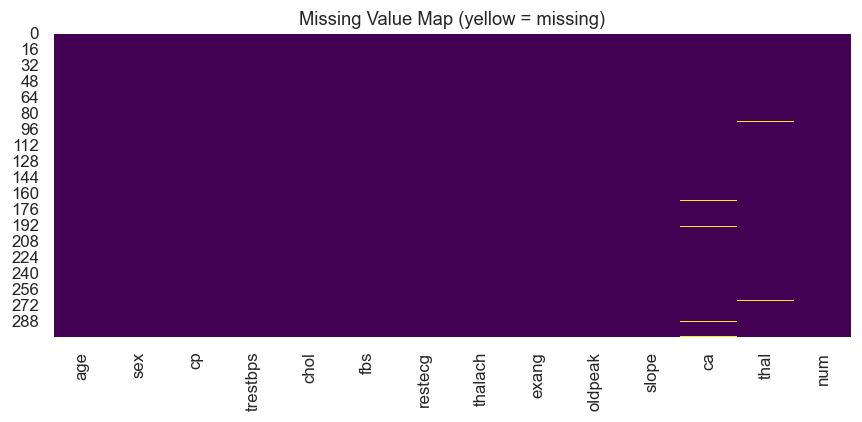

In [5]:
missing = raw.isna().sum()
missing_pct = (missing / len(raw) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df.missing_count > 0]
print("Columns with missing values:")
display(missing_df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(raw.isna(), cbar=False, cmap="viridis", ax=ax)
ax.set_title("Missing Value Map (yellow = missing)")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_missing_values.png", bbox_inches="tight")
plt.show()

## 3. Clean data & engineer the binary target

The original `num` column is a 0-4 diagnosis severity. Following the assignment,
we convert it to a **binary target** (`0` = no disease, `1` = disease present)
and median-impute the missing `ca`/`thal` values.

In [6]:
from src.data_preprocessing import clean_data

df = clean_data(raw)
print("Cleaned shape:", df.shape)
print("Remaining missing values:", int(df.isna().sum().sum()))
df.head()

Cleaned shape: (303, 14)
Remaining missing values: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 4. Class (target) distribution

target
0    164
1    139
Name: count, dtype: int64


C:\Users\saqib\AppData\Local\Temp\ipykernel_23532\4000353231.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Disease (0)", "Disease (1)"])


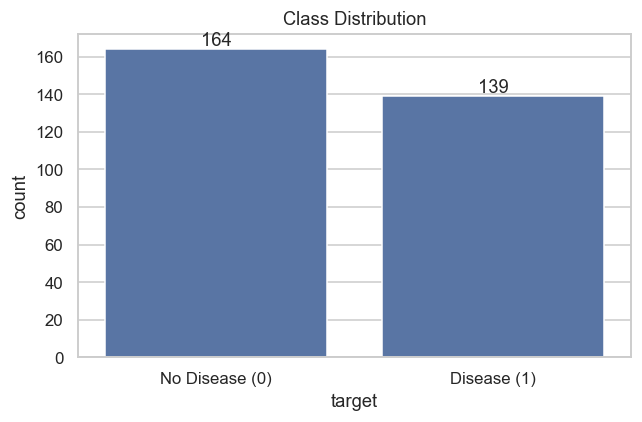

Class balance is roughly 54%/46% - no severe imbalance.


In [7]:
target_counts = df["target"].value_counts().sort_index()
print(target_counts)

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="target", data=df, ax=ax)
ax.set_xticklabels(["No Disease (0)", "Disease (1)"])
ax.set_title("Class Distribution")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_class_balance.png", bbox_inches="tight")
plt.show()
print("Class balance is roughly 54%/46% - no severe imbalance.")

## 5. Histograms of numeric features

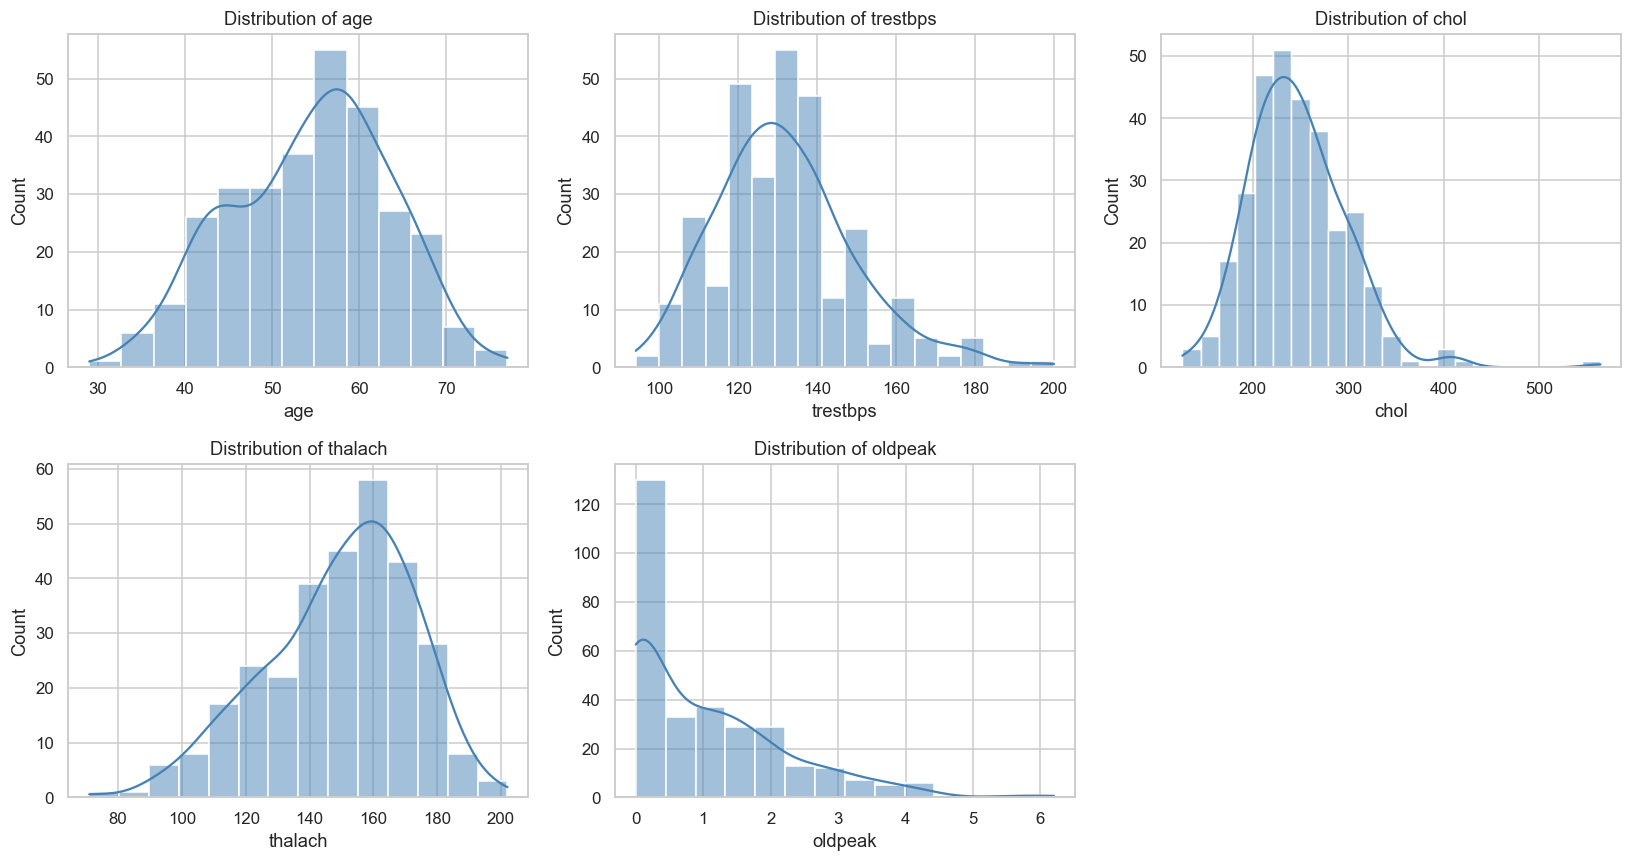

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), NUMERIC_FEATURES):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_histograms.png", bbox_inches="tight")
plt.show()

## 6. Correlation heatmap

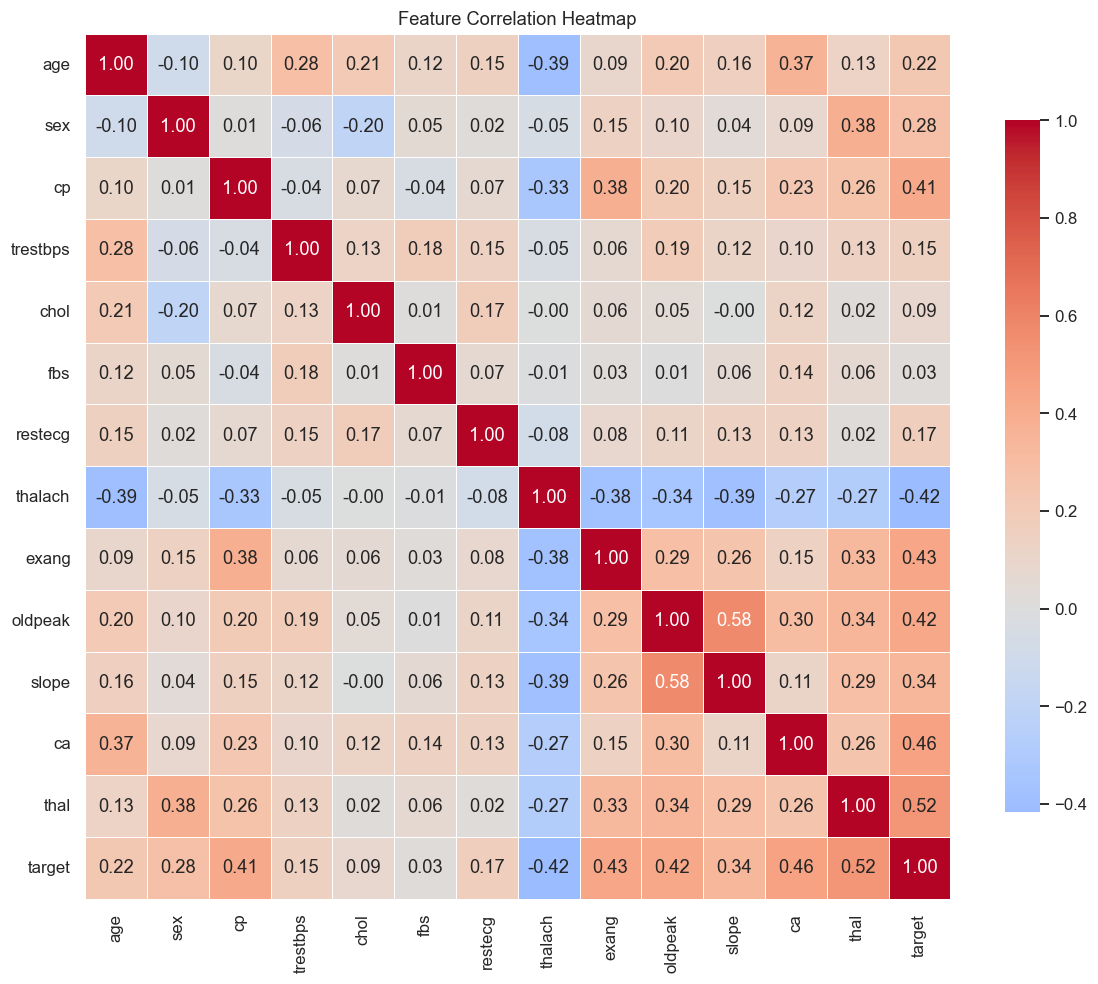

Top correlations with target:
thal        0.522
ca          0.460
exang       0.432
oldpeak     0.425
thalach    -0.417
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025
Name: target, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("Top correlations with target:")
print(corr["target"].drop("target").sort_values(key=abs, ascending=False).round(3))

## 7. Feature-vs-target relationship analysis

Numeric features split by disease status (box plots) and categorical features
as grouped counts.

C:\Users\saqib\AppData\Local\Temp\ipykernel_23532\1589358792.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])
C:\Users\saqib\AppData\Local\Temp\ipykernel_23532\1589358792.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])
C:\Users\saqib\AppData\Local\Temp\ipykernel_23532\1589358792.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])
C:\Users\saqib\AppData\Local\Temp\ipykernel_23532\1589358792.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])
C:\Users\saqib\AppData\Local\Temp\ipykernel_23532\1589358792.py:4: UserWarni

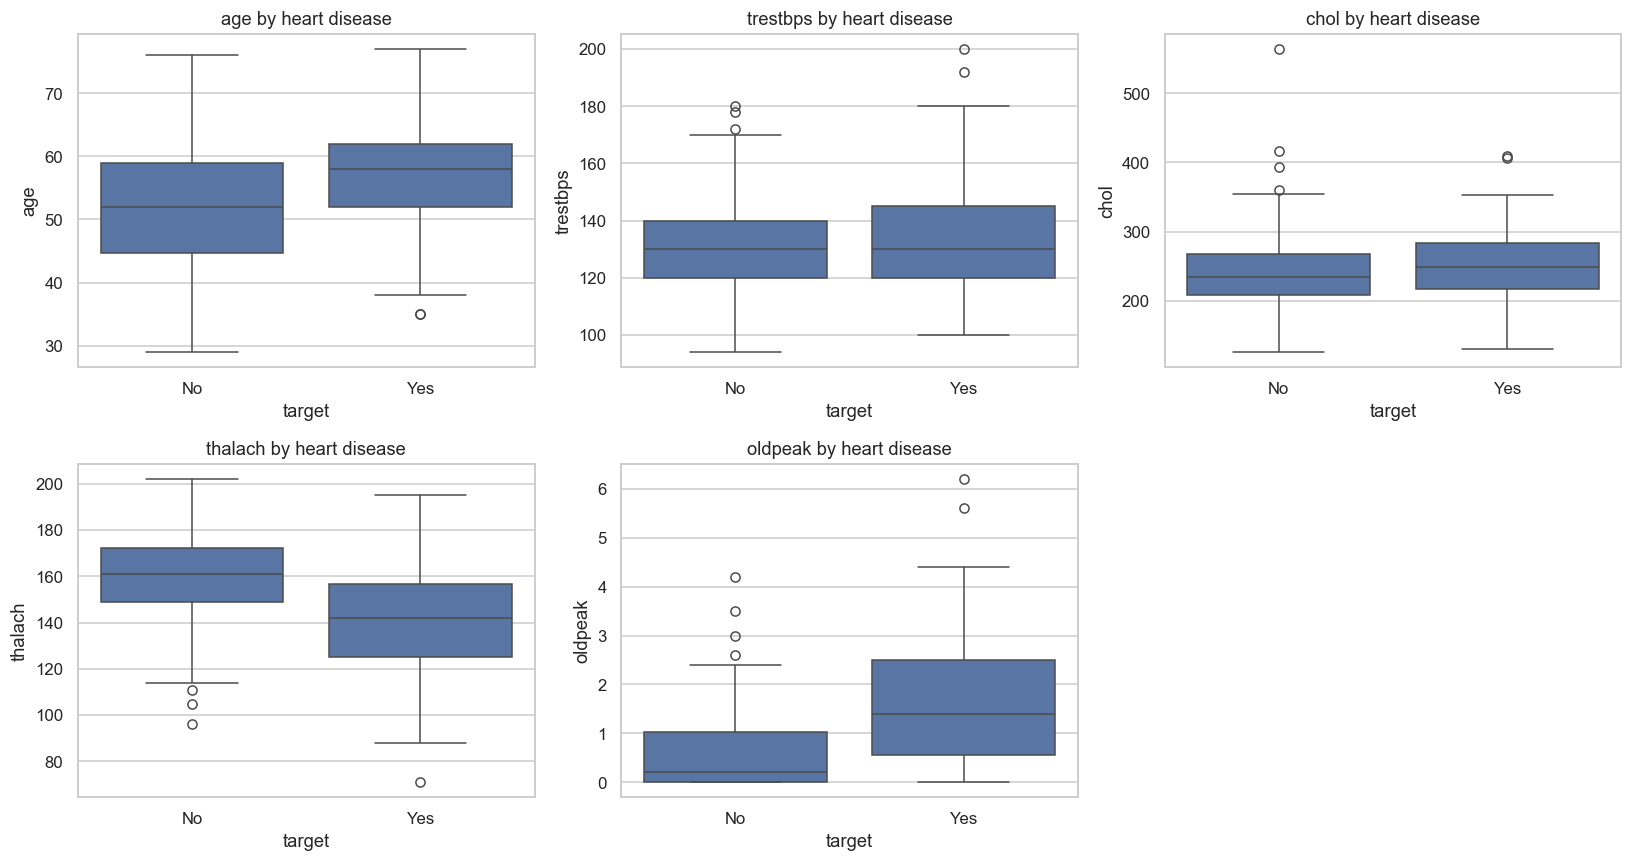

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), NUMERIC_FEATURES):
    sns.boxplot(x="target", y=col, data=df, ax=ax)
    ax.set_xticklabels(["No", "Yes"])
    ax.set_title(f"{col} by heart disease")
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_numeric_vs_target.png", bbox_inches="tight")
plt.show()

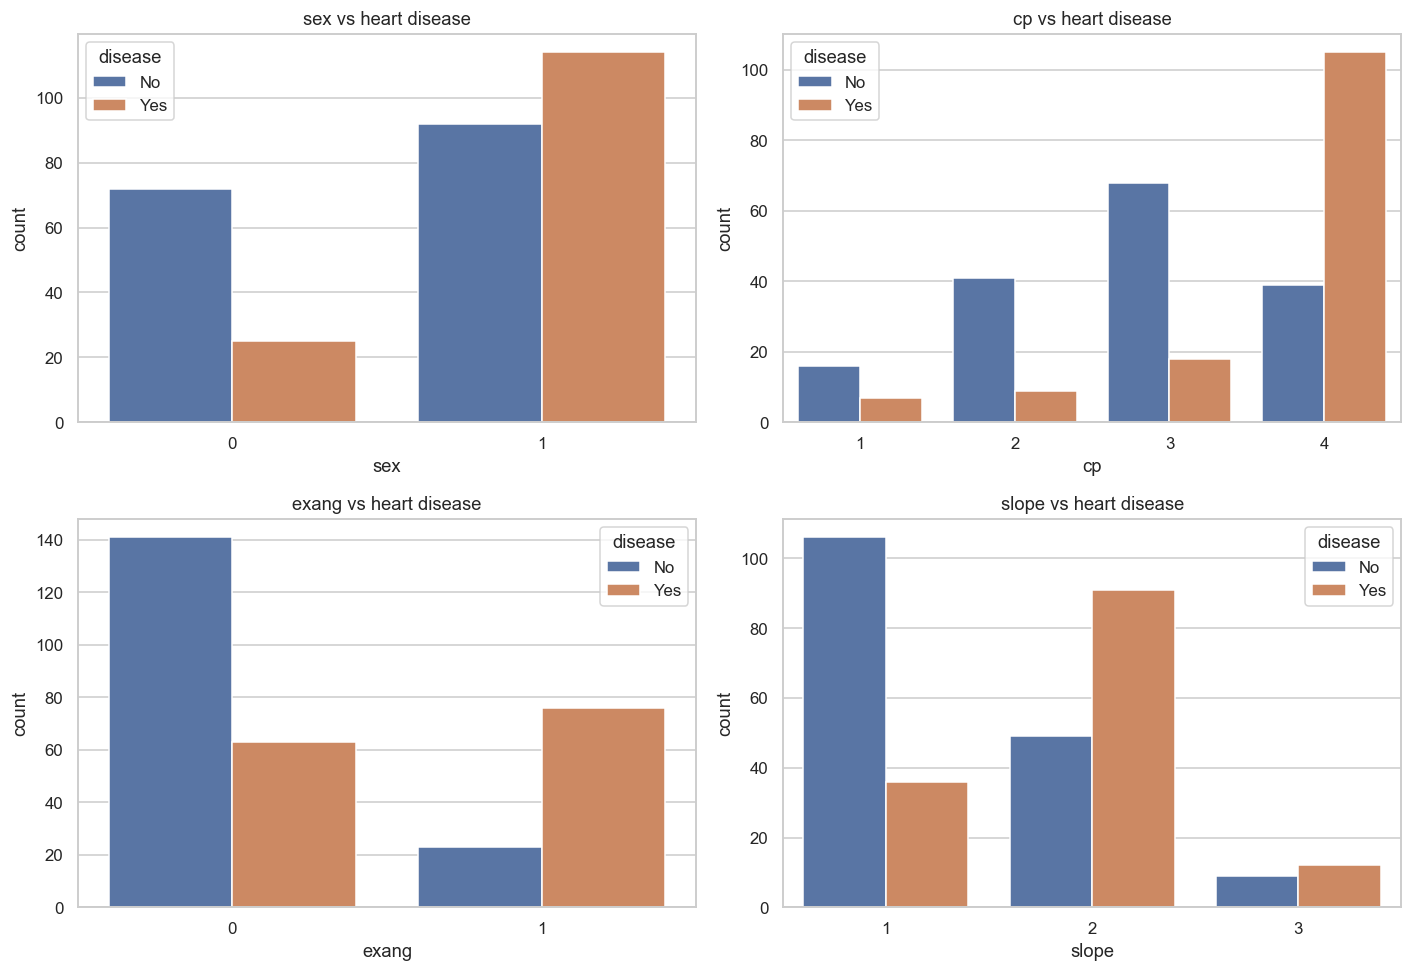

In [11]:
cat_show = ["sex", "cp", "exang", "slope"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), cat_show):
    sns.countplot(x=col, hue="target", data=df, ax=ax)
    ax.set_title(f"{col} vs heart disease")
    ax.legend(title="disease", labels=["No", "Yes"])
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_categorical_vs_target.png", bbox_inches="tight")
plt.show()

## 8. EDA Summary / Findings

* **303 patients, 13 features**, binary target with a healthy ~54/46 class split.
* Only **`ca` and `thal`** had missing values (a handful of rows) - median imputed.
* Strongest positive correlates of heart disease: **`cp` (chest pain type),
  `oldpeak`, `exang`, `ca`, `thal`**.
* Strongest negative correlate: **`thalach` (max heart rate)** - patients with
  disease tend to reach a lower peak heart rate.
* Numeric features are on very different scales (age vs oldpeak) -> **scaling is
  required** before Logistic Regression.
* Categorical clinical codes (`cp`, `thal`, `slope`, ...) -> **one-hot encoding**.

These findings drive the preprocessing pipeline used in `02_training.ipynb`.